In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import datetime
#Smart file locator
if os.path.exists("data/data/SPY_15m_data.csv"):
    target_file = "data/data/SPY_15m_data.csv"
else:
    target_file = "data/SPY_15m_data.csv"

#Load the data 
data = pd.read_csv(target_file, index_col=0, parse_dates=True)

#Rebuild the core baselines for comparison
data['market_return'] = data['close'].pct_change()
data['buy_and_hold'] = (1 + data['market_return']).cumprod()

#Clean up the first empty row
data.dropna(inplace=True)

print(f"Environment ready! Data loaded and baselines calculated. Total rows: {len(data)}")

Environment ready! Data loaded and baselines calculated. Total rows: 1559


In [17]:

data['date'] = data.index.date
data['time'] = data.index.time

#CBDR
cbdr_mask = (data['time'] >= datetime.time(14, 0)) & (data['time'] <= datetime.time(20, 0))
cbdr_levels = data[cbdr_mask].groupby('date').agg(
    CBDR_High=('high', 'max'),
    CBDR_Low=('low', 'min')
).shift(1) 

#Asia
premarket_mask = (data['time'] >= datetime.time(4, 0)) & (data['time'] < datetime.time(9, 30))
premarket_levels = data[premarket_mask].groupby('date').agg(
    PM_High=('high', 'max'),
    PM_Low=('low', 'min')
) 

#Cleanly map the ranges back into the main dataframe
data['CBDR_High'] = data['date'].map(cbdr_levels['CBDR_High'])
data['CBDR_Low'] = data['date'].map(cbdr_levels['CBDR_Low'])
data['PM_High'] = data['date'].map(premarket_levels['PM_High'])
data['PM_Low'] = data['date'].map(premarket_levels['PM_Low'])

#Judas
killzone_mask = (data['time'] >= datetime.time(9, 30)) & (data['time'] <= datetime.time(11, 0))

# Short Traps: Price sweeps ABOVE the High of either session, but closes BELOW it
short_trap_cbdr = killzone_mask & (data['high'] > data['CBDR_High']) & (data['close'] < data['CBDR_High'])
short_trap_pm = killzone_mask & (data['high'] > data['PM_High']) & (data['close'] < data['PM_High'])
short_trap = short_trap_cbdr | short_trap_pm  # The '|' means OR

#Long Traps: Price sweeps BELOW the Low of either session, but closes ABOVE it
long_trap_cbdr = killzone_mask & (data['low'] < data['CBDR_Low']) & (data['close'] > data['CBDR_Low'])
long_trap_pm = killzone_mask & (data['low'] < data['PM_Low']) & (data['close'] > data['PM_Low'])
long_trap = long_trap_cbdr | long_trap_pm    # The '|' means OR

#Execution
data['ict_signal'] = 0
data.loc[long_trap, 'ict_signal'] = 1
data.loc[short_trap, 'ict_signal'] = -1

#Hold the position for the rest of the day (Forward Fill)
data['ict_position'] = data['ict_signal'].replace(0, np.nan).groupby(data['date']).ffill().fillna(0)

#Force Exit at 3:45 PM (Intraday Model)
exit_mask = data['time'] >= datetime.time(15, 45)
data.loc[exit_mask, 'ict_position'] = 0
stop_loss_pct = 0.005
data['active_position'] = data['ict_position'].shift(1).fillna(0).infer_objects(copy=False)
data['ict_raw_ret'] = data['active_position'] * data['market_return']
data['running_pnl'] = data.groupby('date')['ict_raw_ret'].transform(lambda x: (1 + x).cumprod() - 1)
data['sl_hit'] = data['running_pnl'] <= -stop_loss_pct
data['sl_locked'] = data.groupby('date')['sl_hit'].cumsum() > 0
data['post_sl'] = data.groupby('date')['sl_locked'].shift(1).fillna(False).astype(bool)
data.loc[data['post_sl'], 'active_position'] = 0

#Recalculate returns based on the strictly managed position
data['ict_sl_ret'] = data['active_position'] * data['market_return']

#Force exact mathematical exit on the breach bar (Hard Stop)
prev_running_pnl = data.groupby('date')['running_pnl'].shift(1).fillna(0).infer_objects(copy=False)
breach_bar = data['sl_locked'] & ~data['post_sl']
exact_sl_ret = ((1 - stop_loss_pct) / (1 + prev_running_pnl)) - 1
data.loc[breach_bar, 'ict_sl_ret'] = exact_sl_ret

#Compound the final true Returns
data['ict_cum_ret'] = (1 + data['ict_sl_ret']).cumprod()
final_return = (data['ict_cum_ret'].iloc[-1] - 1) * 100
buy_hold_return = (data['buy_and_hold'].iloc[-1] - 1) * 100

#Count total trades accurately by only counting new entries
data['new_trade'] = (data['active_position'] != 0) & (data['active_position'] != data['active_position'].shift(1))
total_trades = data['new_trade'].sum()

print("--- PHASE 1: MECHANICAL ICT (TRUE STOP LOSS APPLIED) ---")
print(f"Buy & Hold Baseline: {buy_hold_return:.2f}%")
print(f"Independent Judas Swing Return: {final_return:.2f}%")
print(f"Total Trades Executed: {total_trades}")

--- PHASE 1: MECHANICAL ICT (TRUE STOP LOSS APPLIED) ---
Buy & Hold Baseline: 5.40%
Independent Judas Swing Return: 1.76%
Total Trades Executed: 37


C:\Users\ismai\AppData\Local\Temp\ipykernel_2196\2820834307.py:74: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['post_sl'] = data.groupby('date')['sl_locked'].shift(1).fillna(False).astype(bool)


In [18]:
data['date'] = data.index.date
data['time'] = data.index.time

#CBDR
cbdr_mask = (data['time'] >= datetime.time(14, 0)) & (data['time'] <= datetime.time(20, 0))
cbdr_levels = data[cbdr_mask].groupby('date').agg(
    CBDR_High=('high', 'max'),
    CBDR_Low=('low', 'min')
).shift(1) 

#Asia
premarket_mask = (data['time'] >= datetime.time(4, 0)) & (data['time'] < datetime.time(9, 30))
premarket_levels = data[premarket_mask].groupby('date').agg(
    PM_High=('high', 'max'),
    PM_Low=('low', 'min')
) 

#Cleanly map the ranges back into the main dataframe
data['CBDR_High'] = data['date'].map(cbdr_levels['CBDR_High'])
data['CBDR_Low'] = data['date'].map(cbdr_levels['CBDR_Low'])
data['PM_High'] = data['date'].map(premarket_levels['PM_High'])
data['PM_Low'] = data['date'].map(premarket_levels['PM_Low'])

#Daily Bias
daily_ohlc = data.groupby('date').agg(
    Daily_Open=('open', 'first'), 
    Daily_Close=('close', 'last')
).shift(1)

#If yesterday closed higher than it opened, Bias = 1 (Bullish). If lower, Bias = -1 (Bearish).
daily_ohlc['Bias'] = np.where(daily_ohlc['Daily_Close'] > daily_ohlc['Daily_Open'], 1, -1)
data['daily_bias'] = data['date'].map(daily_ohlc['Bias'])

#Judas swing
killzone_mask = (data['time'] >= datetime.time(9, 30)) & (data['time'] <= datetime.time(11, 0))
short_trap_cbdr = killzone_mask & (data['high'] > data['CBDR_High']) & (data['close'] < data['CBDR_High'])
short_trap_pm = killzone_mask & (data['high'] > data['PM_High']) & (data['close'] < data['PM_High'])
short_trap_raw = short_trap_cbdr | short_trap_pm  
long_trap_cbdr = killzone_mask & (data['low'] < data['CBDR_Low']) & (data['close'] > data['CBDR_Low'])
long_trap_pm = killzone_mask & (data['low'] < data['PM_Low']) & (data['close'] > data['PM_Low'])
long_trap_raw = long_trap_cbdr | long_trap_pm    
short_trap = short_trap_raw & (data['daily_bias'] == -1)
long_trap = long_trap_raw & (data['daily_bias'] == 1)

#Execution
data['ict_signal'] = 0
data.loc[long_trap, 'ict_signal'] = 1
data.loc[short_trap, 'ict_signal'] = -1

#Hold the position for the rest of the day (Forward Fill)
data['ict_position'] = data['ict_signal'].replace(0, np.nan).groupby(data['date']).ffill().fillna(0)

#Force Exit at 3:45 PM (Intraday Model)
exit_mask = data['time'] >= datetime.time(15, 45)
data.loc[exit_mask, 'ict_position'] = 0
stop_loss_pct = 0.005
data['active_position'] = data['ict_position'].shift(1).fillna(0).infer_objects(copy=False)
data['ict_raw_ret'] = data['active_position'] * data['market_return']
data['running_pnl'] = data.groupby('date')['ict_raw_ret'].transform(lambda x: (1 + x).cumprod() - 1)
data['sl_hit'] = data['running_pnl'] <= -stop_loss_pct
data['sl_locked'] = data.groupby('date')['sl_hit'].cumsum() > 0
data['post_sl'] = data.groupby('date')['sl_locked'].shift(1).fillna(False).astype(bool)
data.loc[data['post_sl'], 'active_position'] = 0
data['ict_sl_ret'] = data['active_position'] * data['market_return']
prev_running_pnl = data.groupby('date')['running_pnl'].shift(1).fillna(0).infer_objects(copy=False)
breach_bar = data['sl_locked'] & ~data['post_sl']
exact_sl_ret = ((1 - stop_loss_pct) / (1 + prev_running_pnl)) - 1
data.loc[breach_bar, 'ict_sl_ret'] = exact_sl_ret
data['ict_cum_ret'] = (1 + data['ict_sl_ret']).cumprod()

#Results
final_return = (data['ict_cum_ret'].iloc[-1] - 1) * 100
buy_hold_return = (data['buy_and_hold'].iloc[-1] - 1) * 100

data['new_trade'] = (data['active_position'] != 0) & (data['active_position'] != data['active_position'].shift(1))
total_trades = data['new_trade'].sum()

print("--- PHASE 2: ICT JUDAS SWING (WITH DAILY BIAS) ---")
print(f"Buy & Hold Baseline: {buy_hold_return:.2f}%")
print(f"Bias-Filtered Return: {final_return:.2f}%")
print(f"Total Trades Executed: {total_trades}")

--- PHASE 2: ICT JUDAS SWING (WITH DAILY BIAS) ---
Buy & Hold Baseline: 5.40%
Bias-Filtered Return: 1.77%
Total Trades Executed: 18


C:\Users\ismai\AppData\Local\Temp\ipykernel_2196\3693507095.py:80: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['post_sl'] = data.groupby('date')['sl_locked'].shift(1).fillna(False).astype(bool)


In [19]:
data['date'] = data.index.date
data['time'] = data.index.time

#CBDR
cbdr_mask = (data['time'] >= datetime.time(14, 0)) & (data['time'] <= datetime.time(20, 0))
cbdr_levels = data[cbdr_mask].groupby('date').agg(
    CBDR_High=('high', 'max'),
    CBDR_Low=('low', 'min')
).shift(1) 

#Asia
premarket_mask = (data['time'] >= datetime.time(4, 0)) & (data['time'] < datetime.time(9, 30))
premarket_levels = data[premarket_mask].groupby('date').agg(
    PM_High=('high', 'max'),
    PM_Low=('low', 'min')
) 

#Cleanly map the ranges back into the main dataframe
data['CBDR_High'] = data['date'].map(cbdr_levels['CBDR_High'])
data['CBDR_Low'] = data['date'].map(cbdr_levels['CBDR_Low'])
data['PM_High'] = data['date'].map(premarket_levels['PM_High'])
data['PM_Low'] = data['date'].map(premarket_levels['PM_Low'])

#Daily Bias
daily_ohlc = data.groupby('date').agg(
    Daily_Open=('open', 'first'), 
    Daily_Close=('close', 'last')
).shift(1)
daily_ohlc['Bias'] = np.where(daily_ohlc['Daily_Close'] > daily_ohlc['Daily_Open'], 1, -1)
data['daily_bias'] = data['date'].map(daily_ohlc['Bias'])

#Judas Swing
killzone_mask = (data['time'] >= datetime.time(9, 30)) & (data['time'] <= datetime.time(11, 0))

# Short Traps (Only if Bias is Bearish -1)
short_trap_cbdr = killzone_mask & (data['high'] > data['CBDR_High']) & (data['close'] < data['CBDR_High']) & (data['daily_bias'] == -1)
short_trap_pm = killzone_mask & (data['high'] > data['PM_High']) & (data['close'] < data['PM_High']) & (data['daily_bias'] == -1)

# Long Traps (Only if Bias is Bullish 1)
long_trap_cbdr = killzone_mask & (data['low'] < data['CBDR_Low']) & (data['close'] > data['CBDR_Low']) & (data['daily_bias'] == 1)
long_trap_pm = killzone_mask & (data['low'] < data['PM_Low']) & (data['close'] > data['PM_Low']) & (data['daily_bias'] == 1)

#Execution
data['ict_signal'] = 0
data.loc[long_trap_cbdr | long_trap_pm, 'ict_signal'] = 1
data.loc[short_trap_cbdr | short_trap_pm, 'ict_signal'] = -1

#Lock the specific target based on which pool was swept
data['tp_target'] = np.nan
data.loc[short_trap_cbdr, 'tp_target'] = data['CBDR_Low']
data.loc[short_trap_pm, 'tp_target'] = data['PM_Low']
data.loc[long_trap_cbdr, 'tp_target'] = data['CBDR_High']
data.loc[long_trap_pm, 'tp_target'] = data['PM_High']

#Forward fill the position and the TP target for the rest of the day
data['ict_position'] = data['ict_signal'].replace(0, np.nan).groupby(data['date']).ffill().fillna(0)
data['active_tp'] = data['tp_target'].groupby(data['date']).ffill()

#Time Stop
exit_mask = data['time'] >= datetime.time(15, 45)
data.loc[exit_mask, 'ict_position'] = 0

#Dynamic TP
stop_loss_pct = 0.005

#Track active position and basic running PnL
data['active_position'] = data['ict_position'].shift(1).fillna(0).infer_objects(copy=False)
data['ict_raw_ret'] = data['active_position'] * data['market_return']
data['running_pnl'] = data.groupby('date')['ict_raw_ret'].transform(lambda x: (1 + x).cumprod() - 1)

#Detect Stop-Loss Hits
data['sl_hit'] = data['running_pnl'] <= -stop_loss_pct

#Detect Take-Profit Hits (Using intraday High/Low Wicks)
tp_hit_short = (data['active_position'] == -1) & (data['low'] <= data['active_tp'])
tp_hit_long = (data['active_position'] == 1) & (data['high'] >= data['active_tp'])
data['tp_hit'] = tp_hit_short | tp_hit_long

#Conservative Collision Rule: If both hit on the same bar, assume Stop-Loss fired first
collision = data['sl_hit'] & data['tp_hit']
data.loc[collision, 'tp_hit'] = False

#Lock the states to ensure the trade dies immediately
data['sl_locked'] = data.groupby('date')['sl_hit'].cumsum() > 0
data['tp_locked'] = data.groupby('date')['tp_hit'].cumsum() > 0
data['trade_dead'] = data['sl_locked'] | data['tp_locked']

#Zero out position for the rest of the day after death
data['post_dead'] = data.groupby('date')['trade_dead'].shift(1).fillna(False).astype(bool)
data.loc[data['post_dead'], 'active_position'] = 0

#Recalculate returns based strictly on surviving positions
data['ict_adjusted_ret'] = data['active_position'] * data['market_return']

#Find exact breach bars
prev_running_pnl = data.groupby('date')['running_pnl'].shift(1).fillna(0).infer_objects(copy=False)
prev_close = data['close'].shift(1)

sl_breach_bar = data['sl_locked'] & ~data['post_dead'] & ~data['tp_locked'].shift(1).fillna(False)
tp_breach_bar = data['tp_locked'] & ~data['post_dead'] & ~data['sl_locked'].shift(1).fillna(False)

#Exact SL Math
exact_sl_ret = ((1 - stop_loss_pct) / (1 + prev_running_pnl)) - 1
data.loc[sl_breach_bar, 'ict_adjusted_ret'] = exact_sl_ret

#Exact TP Math (Calculated from previous bar's close to the absolute TP target)
exact_tp_ret = (data['active_tp'] - prev_close) / prev_close * data['active_position']
data.loc[tp_breach_bar, 'ict_adjusted_ret'] = exact_tp_ret

#Compound Final Returns
data['ict_cum_ret'] = (1 + data['ict_adjusted_ret']).cumprod()

#Results
final_return = (data['ict_cum_ret'].iloc[-1] - 1) * 100
buy_hold_return = (data['buy_and_hold'].iloc[-1] - 1) * 100

data['new_trade'] = (data['active_position'] != 0) & (data['active_position'] != data['active_position'].shift(1))
total_trades = data['new_trade'].sum()

print("--- PHASE 3: ICT JUDAS SWING (BIAS + DYNAMIC TP) ---")
print(f"Buy & Hold Baseline: {buy_hold_return:.2f}%")
print(f"Phase 3 Final Return: {final_return:.2f}%")
print(f"Total Trades Executed: {total_trades}")

--- PHASE 3: ICT JUDAS SWING (BIAS + DYNAMIC TP) ---
Buy & Hold Baseline: 5.40%
Phase 3 Final Return: 0.67%
Total Trades Executed: 18


C:\Users\ismai\AppData\Local\Temp\ipykernel_2196\1119878633.py:94: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['post_dead'] = data.groupby('date')['trade_dead'].shift(1).fillna(False).astype(bool)
C:\Users\ismai\AppData\Local\Temp\ipykernel_2196\1119878633.py:104: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sl_breach_bar = data['sl_locked'] & ~data['post_dead'] & ~data['tp_locked'].shift(1).fillna(False)
C:\Users\ismai\AppData\Local\Temp\ipykernel_2196\1119878633.py:105: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill i

C:\Users\ismai\AppData\Local\Temp\ipykernel_2196\1517905576.py:73: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['post_sl'] = data.groupby('date')['sl_locked'].shift(1).fillna(False).astype(bool)


Running 1000 Monte Carlo simulations. Please wait...



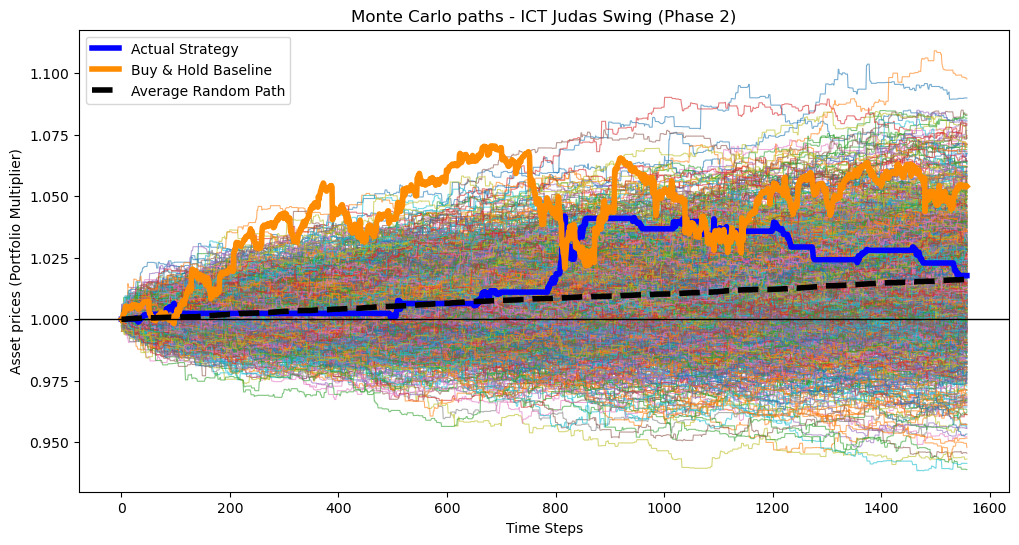

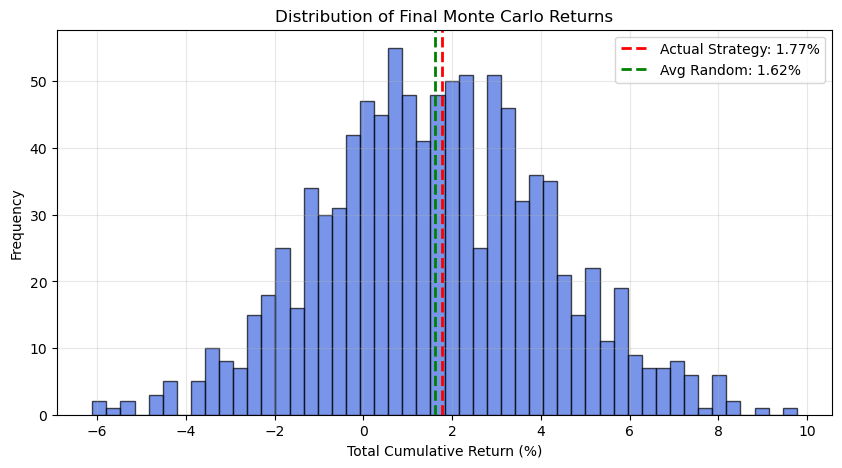

--- MONTE CARLO STATISTICS ---
Actual Strategy Return:    1.77%
Average Random Return:     1.62%
P-Value (Prob. of luck):   0.4750


In [22]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt

# --- 1. PREPARE TIME DATA ---
data['date'] = data.index.date
data['time'] = data.index.time

# --- 2. CALCULATE LIQUIDITY POOLS ---
# CBDR
cbdr_mask = (data['time'] >= datetime.time(14, 0)) & (data['time'] <= datetime.time(20, 0))
cbdr_levels = data[cbdr_mask].groupby('date').agg(
    CBDR_High=('high', 'max'),
    CBDR_Low=('low', 'min')
).shift(1) 

# Asia / Pre-Market
premarket_mask = (data['time'] >= datetime.time(4, 0)) & (data['time'] < datetime.time(9, 30))
premarket_levels = data[premarket_mask].groupby('date').agg(
    PM_High=('high', 'max'),
    PM_Low=('low', 'min')
) 

# Cleanly map the ranges back into the main dataframe
data['CBDR_High'] = data['date'].map(cbdr_levels['CBDR_High'])
data['CBDR_Low'] = data['date'].map(cbdr_levels['CBDR_Low'])
data['PM_High'] = data['date'].map(premarket_levels['PM_High'])
data['PM_Low'] = data['date'].map(premarket_levels['PM_Low'])

# --- 3. CALCULATE DAILY BIAS ---
daily_ohlc = data.groupby('date').agg(
    Daily_Open=('open', 'first'), 
    Daily_Close=('close', 'last')
).shift(1)

daily_ohlc['Bias'] = np.where(daily_ohlc['Daily_Close'] > daily_ohlc['Daily_Open'], 1, -1)
data['daily_bias'] = data['date'].map(daily_ohlc['Bias'])

# --- 4. DEFINE THE JUDAS SWING ---
killzone_mask = (data['time'] >= datetime.time(9, 30)) & (data['time'] <= datetime.time(11, 0))

short_trap_cbdr = killzone_mask & (data['high'] > data['CBDR_High']) & (data['close'] < data['CBDR_High'])
short_trap_pm = killzone_mask & (data['high'] > data['PM_High']) & (data['close'] < data['PM_High'])
short_trap_raw = short_trap_cbdr | short_trap_pm  

long_trap_cbdr = killzone_mask & (data['low'] < data['CBDR_Low']) & (data['close'] > data['CBDR_Low'])
long_trap_pm = killzone_mask & (data['low'] < data['PM_Low']) & (data['close'] > data['PM_Low'])
long_trap_raw = long_trap_cbdr | long_trap_pm    

short_trap = short_trap_raw & (data['daily_bias'] == -1)
long_trap = long_trap_raw & (data['daily_bias'] == 1)

# --- 5. EXECUTION ---
data['ict_signal'] = 0
data.loc[long_trap, 'ict_signal'] = 1
data.loc[short_trap, 'ict_signal'] = -1

data['ict_position'] = data['ict_signal'].replace(0, np.nan).groupby(data['date']).ffill().fillna(0)

exit_mask = data['time'] >= datetime.time(15, 45)
data.loc[exit_mask, 'ict_position'] = 0

# --- 6. CALCULATE RETURNS & HARD STOP-LOSS ---
stop_loss_pct = 0.005
data['active_position'] = data['ict_position'].shift(1).fillna(0).infer_objects(copy=False)
data['ict_raw_ret'] = data['active_position'] * data['market_return']

data['running_pnl'] = data.groupby('date')['ict_raw_ret'].transform(lambda x: (1 + x).cumprod() - 1)
data['sl_hit'] = data['running_pnl'] <= -stop_loss_pct
data['sl_locked'] = data.groupby('date')['sl_hit'].cumsum() > 0

data['post_sl'] = data.groupby('date')['sl_locked'].shift(1).fillna(False).astype(bool)
data.loc[data['post_sl'], 'active_position'] = 0

data['ict_sl_ret'] = data['active_position'] * data['market_return']
prev_running_pnl = data.groupby('date')['running_pnl'].shift(1).fillna(0).infer_objects(copy=False)
breach_bar = data['sl_locked'] & ~data['post_sl']

exact_sl_ret = ((1 - stop_loss_pct) / (1 + prev_running_pnl)) - 1
data.loc[breach_bar, 'ict_sl_ret'] = exact_sl_ret

strategy_returns = data['ict_sl_ret'].dropna()
aligned_market_returns = data.loc[strategy_returns.index, 'market_return']
baseline_path = (1 + aligned_market_returns).cumprod().values

actual_path = (1 + strategy_returns).cumprod().values

# --- 7. MONTE CARLO SIMULATION (1,000 ITERATIONS) ---
num_simulations = 1000
simulated_paths = np.zeros((len(strategy_returns), num_simulations))

print(f"Running {num_simulations} Monte Carlo simulations. Please wait...\n")

for i in range(num_simulations):
    random_returns = np.random.choice(strategy_returns, size=len(strategy_returns), replace=True)
    simulated_paths[:, i] = (1 + random_returns).cumprod()

average_path = np.mean(simulated_paths, axis=1)

# --- 8. VISUALISATION (MATCHING YOUR MA STYLE) ---
plt.figure(figsize=(12, 6))
plt.plot(simulated_paths, alpha=0.6, linewidth=0.8)

plt.plot(actual_path, color='blue', linewidth=4, label='Actual Strategy')
plt.plot(baseline_path, color='darkorange', linewidth=4, label='Buy & Hold Baseline')
plt.plot(average_path, color='black', linewidth=4, linestyle='--', label='Average Random Path')

plt.axhline(1.0, color='black', linewidth=1)
plt.title('Monte Carlo paths - ICT Judas Swing (Phase 2)')
plt.xlabel('Time Steps')
plt.ylabel('Asset prices (Portfolio Multiplier)')
plt.legend(loc='upper left')
plt.grid(False) 
plt.show()

final_sim_returns = (simulated_paths[-1, :] - 1) * 100
actual_final_return = (actual_path[-1] - 1) * 100

paths_beating_actual = np.sum(final_sim_returns >= actual_final_return)
p_value = paths_beating_actual / num_simulations

plt.figure(figsize=(10, 5))
plt.hist(final_sim_returns, bins=50, color='royalblue', edgecolor='black', alpha=0.7)
plt.axvline(actual_final_return, color='red', linestyle='dashed', linewidth=2, label=f'Actual Strategy: {actual_final_return:.2f}%')
plt.axvline(np.mean(final_sim_returns), color='green', linestyle='dashed', linewidth=2, label=f'Avg Random: {np.mean(final_sim_returns):.2f}%')
plt.title('Distribution of Final Monte Carlo Returns')
plt.xlabel('Total Cumulative Return (%)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 9. FINAL STATS ---
print("--- MONTE CARLO STATISTICS ---")
print(f"Actual Strategy Return:    {actual_final_return:.2f}%")
print(f"Average Random Return:     {np.mean(final_sim_returns):.2f}%")
print(f"P-Value (Prob. of luck):   {p_value:.4f}")